# Model Testing Notebook

Imports

In [58]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, Sequential
from keras.utils import image_dataset_from_directory

# model building imports
from keras import Model, Sequential, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, RandAugment, GlobalAveragePooling2D, GlobalMaxPool2D, Dropout, RandomRotation, RandomFlip
from keras.optimizers import SGD, Adam
from keras.losses import CategoricalCrossentropy
from keras.metrics import CategoricalAccuracy, AUC, F1Score
from keras.callbacks import EarlyStopping

#Model Class
from keras import Model

In [ ]:
# Check for GPU devices
gpus = tf.config.list_physical_devices('GPU')
gpus

In [ ]:
for gpu in gpus:
    # tf.config.experimental.set_memory_growth(gpu, True)
    tf.config.set_logical_device_configuration(
        gpu,
        [tf.config.LogicalDeviceConfiguration(memory_limit=round(7.5*1024))] # allocate 7.5GB of VRAM
    )

Import data sample and split

In [21]:
train_sample_df, val_sample_df = image_dataset_from_directory(
    "wikiart_sample",
    label_mode= "categorical",
    image_size=(512,512),
    seed=42,
    interpolation="bilinear",
    batch_size=64,
    validation_split = 0.2,
    subset="both"
)

Found 2656 files belonging to 23 classes.
Using 2125 files for training.
Using 531 files for validation.


Import all data and split

In [77]:
train_df, val_df = image_dataset_from_directory(
    "wikiart_datasets",
    label_mode= "categorical",
    image_size=(512,512),
    seed=42,
    interpolation="bilinear",
    batch_size=4,
    validation_split = 0.2,
    subset="both"
)

Found 13340 files belonging to 23 classes.
Using 10672 files for training.
Using 2668 files for validation.


In [10]:
input_shape= (512,512,3)

In [6]:
First_model = Sequential(
    layers= [Input(input_shape),
             Rescaling(scale= 1./255),

             #Primeira Convolutional
             Conv2D(filters=30, kernel_size=(3,3), activation="relu"),
             MaxPooling2D(pool_size=(2,2)),

            #Segunda Convolutional
             Conv2D(filters=60, kernel_size=(3,3), activation="relu"),
             MaxPooling2D(pool_size=(2,2)),

            #Terceira Convolutional
             Conv2D(filters=120, kernel_size=(3,3), activation="relu"),
             MaxPooling2D(pool_size=(2,2)),
              
            #Flatten e Dense layer
            Flatten(),

            #Primeiro Dense layer com mais neurons
            Dense(40, activation="relu"),

            #Second dense layer
            Dense(23, activation="softmax")
            
               ])


In [8]:
First_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 510, 510, 30)   │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 255, 255, 30)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 253, 253, 60)   │        16,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 126, 126, 60)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 124, 124, 120)  │        64,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 62, 62, 120)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 461280)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 40)             │    18,451,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 23)             │           943 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,534,203 (70.70 MB)

 Trainable params: 18,534,203 (70.70 MB)

 Non-trainable params: 0 (0.00 B)

Próxima parte temos de definar o que vai no Comlile, ou seja:

- A loss function
- O optimizer 
- As metrics

In [ ]:
optimizer = SGD(learning_rate=0.01, name="optimizer")
loss = CategoricalCrossentropy(name="loss")

In [ ]:
# metrics usadas para todos os modelos
categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]

In [15]:
#Dar compile com o que acabamos de definir
First_model.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [ ]:
#Defenir número de epoches 

epochs = 10


In [ ]:
#Dar fit do modelo de sample

First_model.fit(
    train_sample_df,
    validation_data=val_sample_df,
    epochs=epochs
)                            #Não é preciso meter batch_size porque já foi especificado quando importarmos os dados

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.0692 - auc: 0.5416 - f1_score: 0.0229 - loss: 3.1570 - val_accuracy: 0.0395 - val_auc: 0.5385 - val_f1_score: 0.0150 - val_loss: 3.1414
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.0795 - auc: 0.5751 - f1_score: 0.0288 - loss: 3.0977 - val_accuracy: 0.1036 - val_auc: 0.5871 - val_f1_score: 0.0256 - val_loss: 3.0853
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.1021 - auc: 0.5980 - f1_score: 0.0362 - loss: 3.0681 - val_accuracy: 0.0603 - val_auc: 0.5467 - val_f1_score: 0.0183 - val_loss: 3.3935
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.1172 - auc: 0.6211 - f1_score: 0.0318 - loss: 3.0340 - val_accuracy: 0.1168 - val_auc: 0.6152 - val_f1_score: 0.0325 - val_loss: 3.0541
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 100s 3s/step - accuracy: 0.1529 - auc: 0.6492 - f1_score: 0.0405 - loss: 2.9779 - val_accuracy: 0.0942 - val_auc: 0.6362 - val_f1_score: 0.0251 - val_loss: 3.032

Dar plot das metrics

In [46]:
def plot_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Loss
    axes[0, 0].plot(history.history['loss'], label='Train')
    axes[0, 0].plot(history.history['val_loss'], label='Val')
    axes[0, 0].set_title('Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0,0].set_ylim(bottom=0)
    axes[0, 0].legend()

    # Accuracy
    axes[0, 1].plot(history.history['accuracy'], label='Train')
    axes[0, 1].plot(history.history['val_accuracy'], label='Val')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0,1].set_ylim(bottom=0)
    axes[0, 1].legend()

    # F1 Score
    axes[1, 0].plot(history.history['f1_score'], label='Train')
    axes[1, 0].plot(history.history['val_f1_score'], label='Val')
    axes[1, 0].set_title('F1 Score')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1 Score')
    axes[1,0].set_ylim(bottom=0)
    axes[1, 0].legend()

    # AUC
    axes[1, 1].plot(history.history['auc'], label='Train')
    axes[1, 1].plot(history.history['val_auc'], label='Val')
    axes[1, 1].set_title('AUC')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('AUC')
    axes[1,1].set_ylim(bottom=0)
    axes[1, 1].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
plot_history(First_model)

Primeiro modelo com todos os dados

In [23]:
AD_first_model =First_model.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)         

Epoch 1/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 480s 3s/step - accuracy: 0.2254 - auc: 0.7462 - f1_score: 0.1151 - loss: 2.7100 - val_accuracy: 0.2095 - val_auc: 0.7509 - val_f1_score: 0.1265 - val_loss: 2.7042
Epoch 2/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 483s 3s/step - accuracy: 0.2567 - auc: 0.7833 - f1_score: 0.1663 - loss: 2.5736 - val_accuracy: 0.2549 - val_auc: 0.7760 - val_f1_score: 0.1660 - val_loss: 2.6005
Epoch 3/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 481s 3s/step - accuracy: 0.2823 - auc: 0.8083 - f1_score: 0.2029 - loss: 2.4657 - val_accuracy: 0.2178 - val_auc: 0.7829 - val_f1_score: 0.1435 - val_loss: 2.6188
Epoch 4/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 479s 3s/step - accuracy: 0.3033 - auc: 0.8273 - f1_score: 0.2314 - loss: 2.3753 - val_accuracy: 0.2676 - val_auc: 0.8070 - val_f1_score: 0.1998 - val_loss: 2.4915
Epoch 5/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 480s 3s/step - accuracy: 0.3343 - auc: 0.8433 - f1_score: 0.2688 - loss: 2.2821 - val_accuracy: 0.2702 - val_auc: 0.7997 - val_f1_score: 0.2084 - va

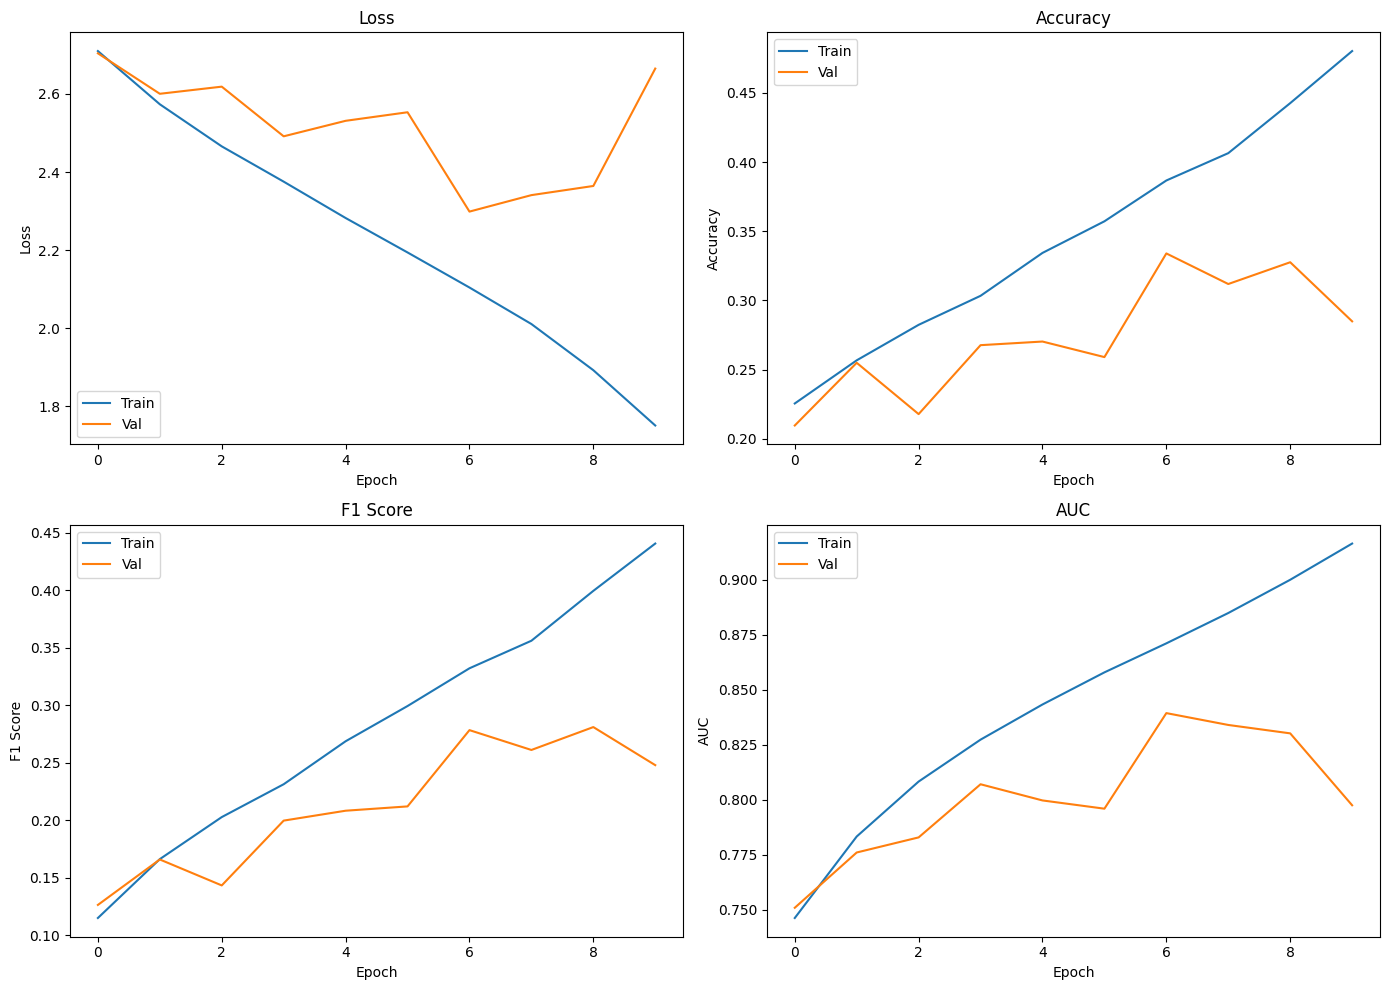

In [ ]:
plot_history(AD_first_model)

In [25]:
print("GPU disponível:", tf.test.is_gpu_available())

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
GPU disponível: False


# Pre-Trained Models

### ResNet

In [6]:
from keras.applications import ResNet50


O Primeiro modelo que vou testar é um ResNet 50, com dois dense layers, e tendo os weights dos modelos pre-trainded freaze

In [17]:
class my_ResNet50_1(Model):
    """
    Pre_trainned ResNet50

    """
    #Initialization
    def __init__(self):
        super().__init__(name="My_ResNet50_1")

        self.n_classes = 23
        self.Rescaling = Rescaling( scale= 1/127.5, offset=-1)
        self.base_model = ResNet50(include_top=False, weights="imagenet", classes=23)
        self.base_model.trainable = False  #Dar freaze ao modelo
        self.Flatten_layer = GlobalMaxPool2D() #Usei GlobalMaxPool2D em vez do Flatten, porque o flatten gera um vetor muito longo
        self.Dense_1 = Dense(120, activation="relu")
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)
        x = self.base_model(x, training = False) #Temos de ter training igual a false, mesmo tendo congelado o modelo em cima, porque                                    
        x = self.Flatten_layer(x)                                       #os batchnormalization layers continuam a treinar e neste primeiro teste não queremos isso
        x = self.Dense_1(x)
        x = self.Dense_2(x)

        return x


In [18]:
first_resnet50 = my_ResNet50_1()
inputs = Input(shape=input_shape)
_ = first_resnet50.call(inputs)
first_resnet50.summary()

Model: "My_ResNet50_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 16, 16, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_2          │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 120)            │       245,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 23)             │         2,783 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,836,375 (90.93 MB)

 Trainable params: 248,663 (971.34 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [10]:
epochs = 10

optimizer = SGD(learning_rate=0.002, name="optimizer")
loss = CategoricalCrossentropy(name="loss")


categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]

In [11]:
#Dar complile do modelo
first_resnet50.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [12]:
first_resnet50_results= first_resnet50.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/10


I0000 00:00:1776005806.349929   29133 service.cc:153] XLA service 0x7429ec067870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776005806.349959   29133 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 12.9.0; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.17.0)
I0000 00:00:1776005806.498530   29133 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776005807.407684   29133 cuda_dnn.cc:461] Loaded cuDNN version 91700
I0000 00:00:1776005807.443507   29133 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10962__.198
W0000 00:00:1776005820.878057   29133 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.53GiB (rounded to 4865688320)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async

166/167 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.1083 - auc: 0.6075 - f1_score: 0.0717 - loss: 4.0049

I0000 00:00:1776005889.746393   29132 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_10962__.198
W0000 00:00:1776005901.888598   29132 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.90GiB (rounded to 4190405376)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1776005901.888758   29132 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1776005901.888769   29132 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 98, Chunks in use: 97. 24.5KiB allocated for chunks. 24.2KiB in use in bin. 9.5KiB client-requested in use in bin.
I0000 00:00:1776005901.888781   29132 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 41, Chunks in use: 41. 20.5KiB allocated for chunks. 20.5KiB in use in bin. 20.5KiB client-requested in use in bin.
I0

167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.1085 - auc: 0.6078 - f1_score: 0.0718 - loss: 4.0003

I0000 00:00:1776005928.230976   31048 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 4 bytes spill stores, 4 bytes spill loads

W0000 00:00:1776005940.266372   29133 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.75GiB (rounded to 4021584640)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1776005940.266415   29133 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1776005940.266418   29133 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 105, Chunks in use: 105. 26.2KiB allocated for chunks. 26.2KiB in use in bin. 9.5KiB client-requested in use in bin.
I0000 00:00:1776005940.266422   29133 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 41, Chunks in use: 41. 20.5KiB allocated 

167/167 ━━━━━━━━━━━━━━━━━━━━ 144s 699ms/step - accuracy: 0.1371 - auc: 0.6578 - f1_score: 0.0865 - loss: 3.2231 - val_accuracy: 0.1683 - val_auc: 0.7081 - val_f1_score: 0.0975 - val_loss: 2.8700
Epoch 2/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 72s 433ms/step - accuracy: 0.1859 - auc: 0.7350 - f1_score: 0.1234 - loss: 2.7838 - val_accuracy: 0.1825 - val_auc: 0.7284 - val_f1_score: 0.0970 - val_loss: 2.8147
Epoch 3/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 72s 430ms/step - accuracy: 0.2058 - auc: 0.7613 - f1_score: 0.1407 - loss: 2.6909 - val_accuracy: 0.2095 - val_auc: 0.7662 - val_f1_score: 0.1477 - val_loss: 2.6677
Epoch 4/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 72s 431ms/step - accuracy: 0.2234 - auc: 0.7781 - f1_score: 0.1579 - loss: 2.6218 - val_accuracy: 0.1844 - val_auc: 0.7642 - val_f1_score: 0.1410 - val_loss: 2.7131
Epoch 5/10
167/167 ━━━━━━━━━━━━━━━━━━━━ 72s 434ms/step - accuracy: 0.2367 - auc: 0.7901 - f1_score: 0.1743 - loss: 2.5713 - val_accuracy: 0.2350 - val_auc: 0.7850 - val_f1_score: 0.1627 - va

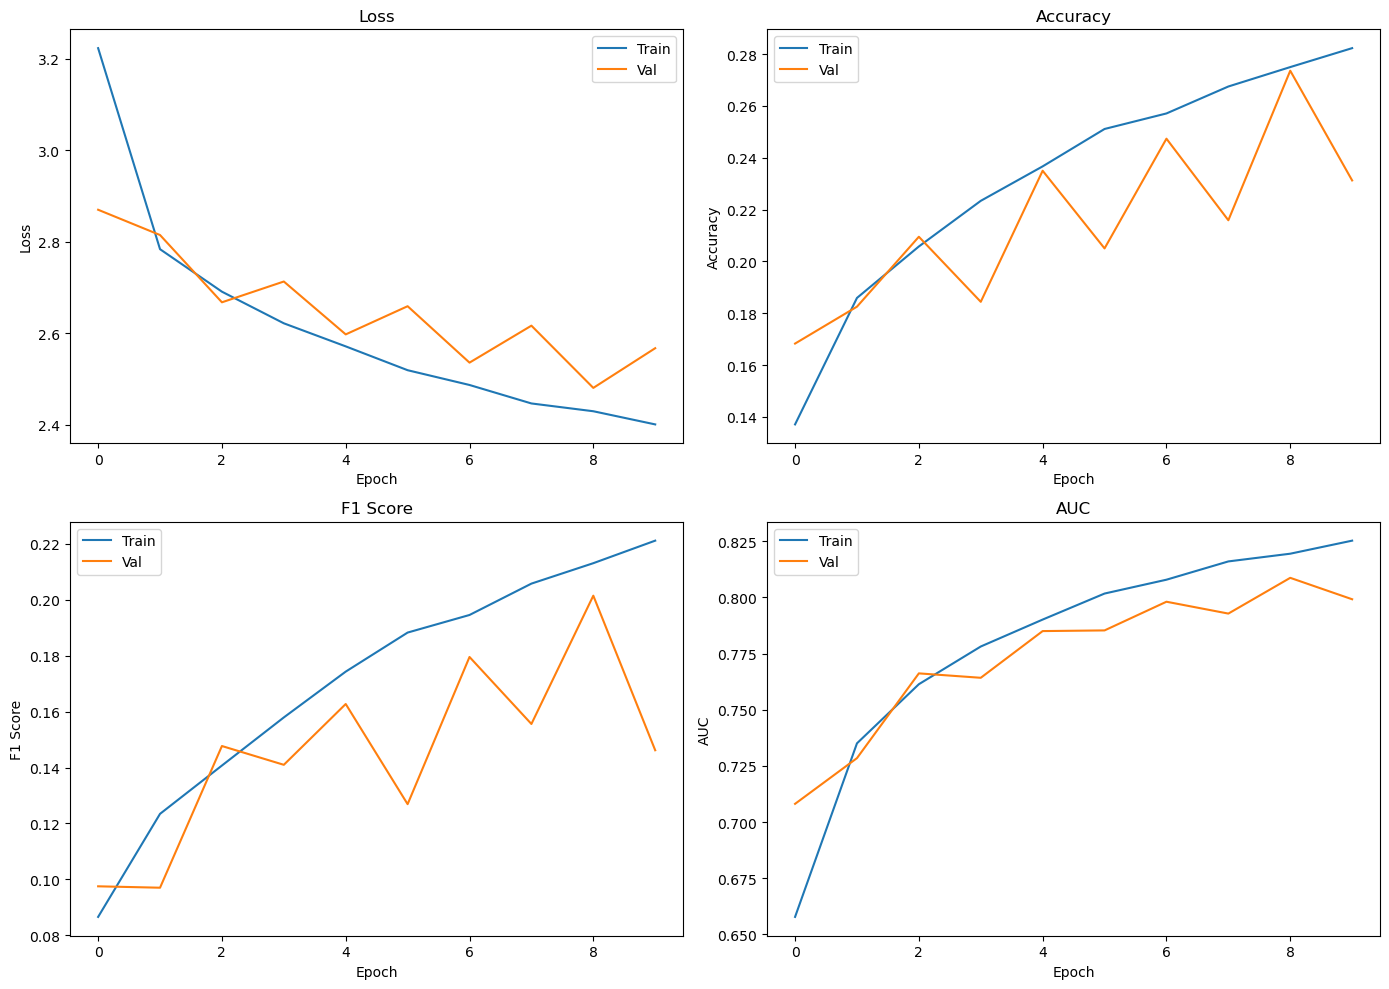

In [13]:
plot_history(first_resnet50_results)

For a first test of ResNet we didn't get the best scores and still got overfiting so we will try to build another model (still with the original ResNet frozen), but with some alterations: (aqui também diminui o batch size de 64 para 32)


- Drop_out (for overfitting)
- Initial Random augmentation (for overfitting) 
- Increasing Learning Rate from 0.002 to 0.004 (trying to increase performance)  
- Increase the number of epoches from 10 to 40 (to see if we have some convergence)

In [5]:
class my_ResNet50_2(Model):
    """
    Pre_trainned ResNet50 + Drop_out + initial random augmentation

    """
    #Initialization
    def __init__(self):
        super().__init__(name="My_ResNet50_2")

        self.n_classes = 23
        self.Rescaling = Rescaling( scale= 1/127.5, offset=-1)
        self.RandAugment = RandAugment(value_range= (-1,1), num_ops = 3, seed=42)
        self.base_model = ResNet50(include_top=False, weights="imagenet", classes=23)
        self.base_model.trainable = False  #Dar freaze ao modelo
        self.Globalmax_layer = GlobalMaxPool2D() #Usei GlobalMaxPool2D em vez do Flatten, porque o flatten gera um vetor muito longo
        self.Dense_1 = Dense(120, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)
        x = self.RandAugment(x)
        x = self.base_model(x, training = False) #Temos de ter training igual a false, mesmo tendo congelado o modelo em cima, porque                                    
        x = self.Globalmax_layer(x)                                       #os batchnormalization layers continuam a treinar e neste primeiro teste não queremos isso
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [23]:
second_resnet50 = my_ResNet50_2()
inputs = Input(shape=input_shape)
_ = second_resnet50.call(inputs)
second_resnet50.summary()

Model: "My_ResNet50_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rand_augment (RandAugment)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 16, 16, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_3          │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 120)            │       245,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 23)             │         2,783 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,836,375 (90.93 MB)

 Trainable params: 248,663 (971.34 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [24]:
epochs = 40

optimizer = SGD(learning_rate=0.004, name="optimizer")
loss = CategoricalCrossentropy(name="loss")


categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]

In [25]:
second_resnet50.compile(loss=loss, optimizer=optimizer, metrics= metrics)

In [26]:
second_resnet50_results= second_resnet50.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40


W0000 00:00:1776014671.690627   29128 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.29GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


334/334 ━━━━━━━━━━━━━━━━━━━━ 304s 876ms/step - accuracy: 0.0821 - auc: 0.5395 - f1_score: 0.0283 - loss: 3.2800 - val_accuracy: 0.1091 - val_auc: 0.5777 - val_f1_score: 0.0209 - val_loss: 3.1212
Epoch 2/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 284s 852ms/step - accuracy: 0.0893 - auc: 0.5827 - f1_score: 0.0303 - loss: 3.0961 - val_accuracy: 0.1057 - val_auc: 0.5866 - val_f1_score: 0.0349 - val_loss: 3.1211
Epoch 3/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 283s 847ms/step - accuracy: 0.1090 - auc: 0.6105 - f1_score: 0.0403 - loss: 3.0543 - val_accuracy: 0.0915 - val_auc: 0.6269 - val_f1_score: 0.0306 - val_loss: 3.0494
Epoch 4/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 285s 854ms/step - accuracy: 0.1168 - auc: 0.6373 - f1_score: 0.0455 - loss: 3.0204 - val_accuracy: 0.1072 - val_auc: 0.6397 - val_f1_score: 0.0345 - val_loss: 3.0256
Epoch 5/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 284s 851ms/step - accuracy: 0.1211 - auc: 0.6572 - f1_score: 0.0481 - loss: 2.9734 - val_accuracy: 0.1271 - val_auc: 0.6550 - val_f1_score: 0.0414 

Com estas alterações o modelo demorou bem mais (também foram mais epochs), mas ao contrário do esperado a performance diminuiu um bocado, mesmo não estando a dar tanto overfit. Ter aumentado o Learning Rate provavelmente foi uma má opção pois o modelo não conseguiu convergir e a performance piorou - > próximo passo treinar este mesmo modelo mas com learning rate mais baixo, para perseber se foi este a causa do problema

- Reduzi Learning rate de 0.004 para 0.001

In [9]:
second_2_Resnet50 = my_ResNet50_2()

In [10]:
epochs = 40
loss = CategoricalCrossentropy(name="loss")
optimizer = SGD(learning_rate=0.001, name="optimizer")


categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]

In [11]:
second_2_Resnet50.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [13]:
second_2_Resnet50_results = second_2_Resnet50.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40


I0000 00:00:1776078481.338460  103189 cuda_dnn.cc:461] Loaded cuDNN version 91700


334/334 ━━━━━━━━━━━━━━━━━━━━ 305s 874ms/step - accuracy: 0.1057 - auc: 0.6295 - f1_score: 0.0590 - loss: 3.1859 - val_accuracy: 0.1169 - val_auc: 0.6619 - val_f1_score: 0.0580 - val_loss: 3.0059
Epoch 2/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 286s 856ms/step - accuracy: 0.1333 - auc: 0.6805 - f1_score: 0.0683 - loss: 2.9464 - val_accuracy: 0.1199 - val_auc: 0.6754 - val_f1_score: 0.0417 - val_loss: 2.9870
Epoch 3/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 283s 849ms/step - accuracy: 0.1519 - auc: 0.6998 - f1_score: 0.0797 - loss: 2.8941 - val_accuracy: 0.1364 - val_auc: 0.6955 - val_f1_score: 0.0642 - val_loss: 2.9062
Epoch 4/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 285s 853ms/step - accuracy: 0.1538 - auc: 0.7089 - f1_score: 0.0857 - loss: 2.8667 - val_accuracy: 0.1525 - val_auc: 0.6989 - val_f1_score: 0.0666 - val_loss: 2.8985
Epoch 5/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 284s 850ms/step - accuracy: 0.1729 - auc: 0.7187 - f1_score: 0.1024 - loss: 2.8330 - val_accuracy: 0.1657 - val_auc: 0.7202 - val_f1_score: 0.0872 

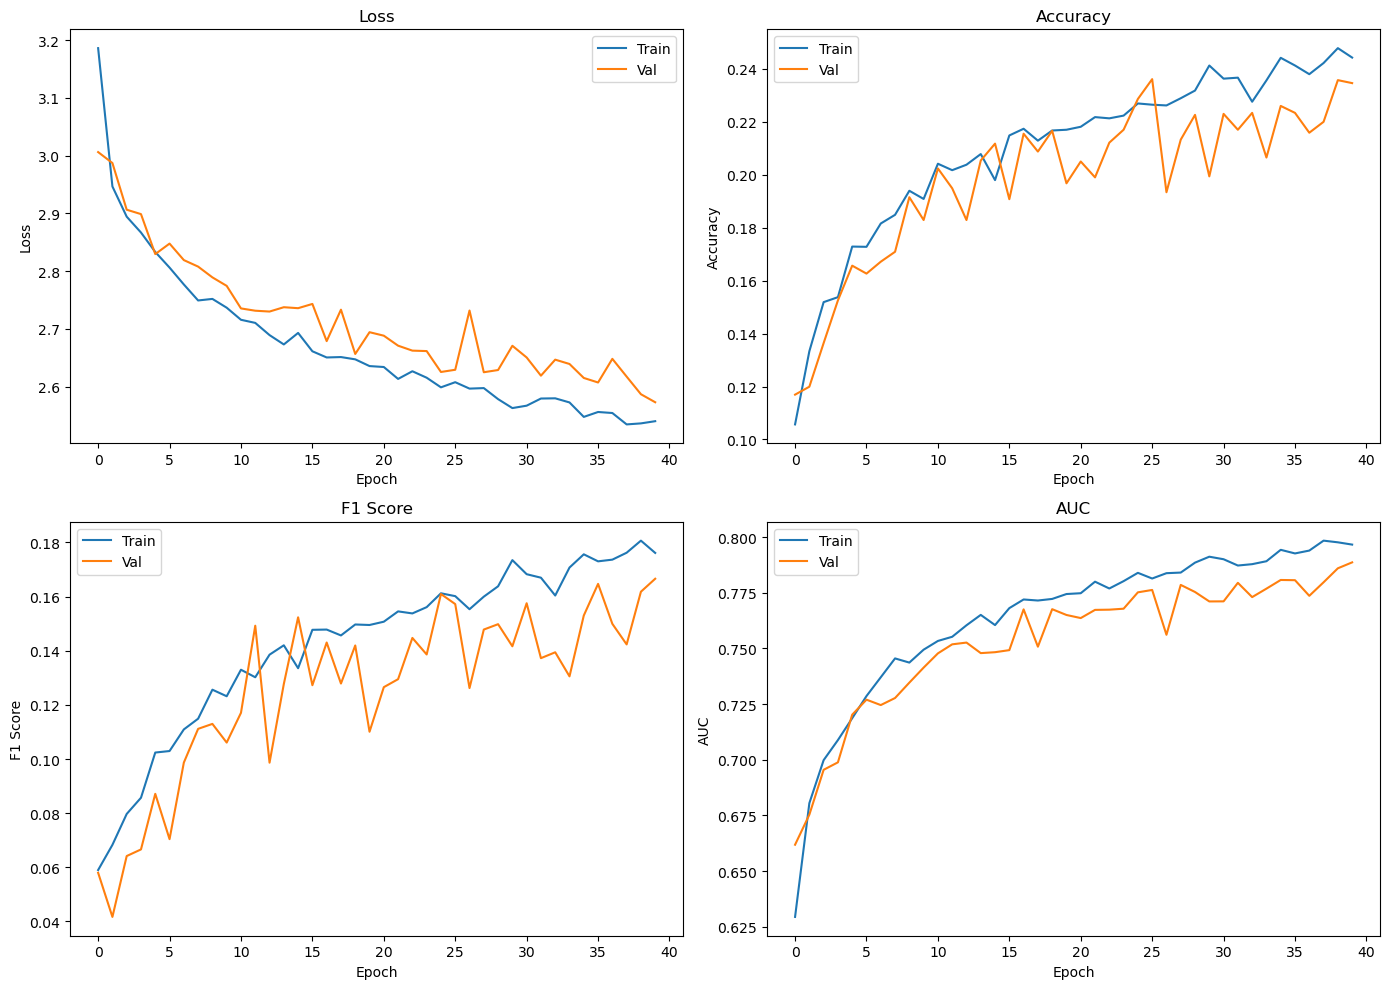

In [14]:
plot_history(second_2_Resnet50_results)

vendo os resultados o modelo não teve tantos saltos drásticos como o anterior o que era esperado tendo em conta a descida de learning rate, optivemos um score melhor mas não muito significativo a meio ver. O overfitting continua controlado o que é bom, mas pode ser por causa de augmentations ou do drop out que o modelo não está a ter tão boas performances como antes de os colocar.

- adicionar augmentations que façam mais sentido para tentar melhorar a performance mas controlando na mesma o overfitting

Augmentations que pensei em adicionar adicionar:

- Horizontal flipping - **I will use this one**
- Random Rotation (small) - **I wil use this one** 
- Random Zoom (testar esta depois se o primeiro teste correr bem)

Estas duas últimas não coloquei porque considero que são key features que identificam o estilo de pintura de um pintor, então decidi não colocar

- Random Brightness / Contrast
- Random Saturation

In [21]:
class my_ResNet50_3(Model):
    """
    Pre_trainned ResNet50 + Drop_out + Random Rotation + Random flip

    """
    #Initialization
    def __init__(self):
        super().__init__(name="My_ResNet50_3")

        self.n_classes = 23
        self.Rescaling = Rescaling( scale= 1/127.5, offset=-1)
        self.RandRotation = RandomRotation(factor=(-0.05, 0.05), fill_mode="reflect", interpolation="bilinear")
        self.RandFlip = RandomFlip(mode="horizontal")
        self.base_model = ResNet50(include_top=False, weights="imagenet", classes=23)
        self.base_model.trainable = False  #Dar freaze ao modelo
        self.Globalmax_layer = GlobalMaxPool2D() #Usei GlobalMaxPool2D em vez do Flatten, porque o flatten gera um vetor muito longo
        self.Dense_1 = Dense(120, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Rescaling(x)
        x = self.RandRotation(x)
        x = self.RandFlip(x)
        x = self.base_model(x, training = False) #Temos de ter training igual a false, mesmo tendo congelado o modelo em cima, porque                                    
        x = self.Globalmax_layer(x)                                       #os batchnormalization layers continuam a treinar e neste primeiro teste não queremos isso
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [22]:
third_resnet50 = my_ResNet50_3()
inputs = Input(shape=input_shape)
_ = third_resnet50.call(inputs)
third_resnet50.summary()

Model: "My_ResNet50_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 512, 512, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 16, 16, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_2          │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 120)            │       245,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 23)             │         2,783 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,836,375 (90.93 MB)

 Trainable params: 248,663 (971.34 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [23]:
epochs = 40
loss = CategoricalCrossentropy(name="loss")
optimizer = SGD(learning_rate=0.001, name="optimizer")


categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]

In [24]:
third_resnet50.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [25]:
third_resnet50_results = third_resnet50.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 181s 520ms/step - accuracy: 0.1345 - auc: 0.6700 - f1_score: 0.0858 - loss: 3.0782 - val_accuracy: 0.1289 - val_auc: 0.6961 - val_f1_score: 0.0506 - val_loss: 3.0974
Epoch 2/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 190s 470ms/step - accuracy: 0.1674 - auc: 0.7295 - f1_score: 0.1081 - loss: 2.8174 - val_accuracy: 0.1451 - val_auc: 0.7131 - val_f1_score: 0.0838 - val_loss: 2.9186
Epoch 3/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 159s 475ms/step - accuracy: 0.1955 - auc: 0.7547 - f1_score: 0.1359 - loss: 2.7241 - val_accuracy: 0.1930 - val_auc: 0.7360 - val_f1_score: 0.1152 - val_loss: 2.7878
Epoch 4/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 158s 474ms/step - accuracy: 0.2124 - auc: 0.7679 - f1_score: 0.1498 - loss: 2.6702 - val_accuracy: 0.2088 - val_auc: 0.7603 - val_f1_score: 0.1279 - val_loss: 2.7078
Epoch 5/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 159s 477ms/step - accuracy: 0.2280 - auc: 0.7815 - f1_score: 0.1688 - loss: 2.6131 - val_accuracy: 0.2193 - val_auc: 0.7739 - val_f1_sco

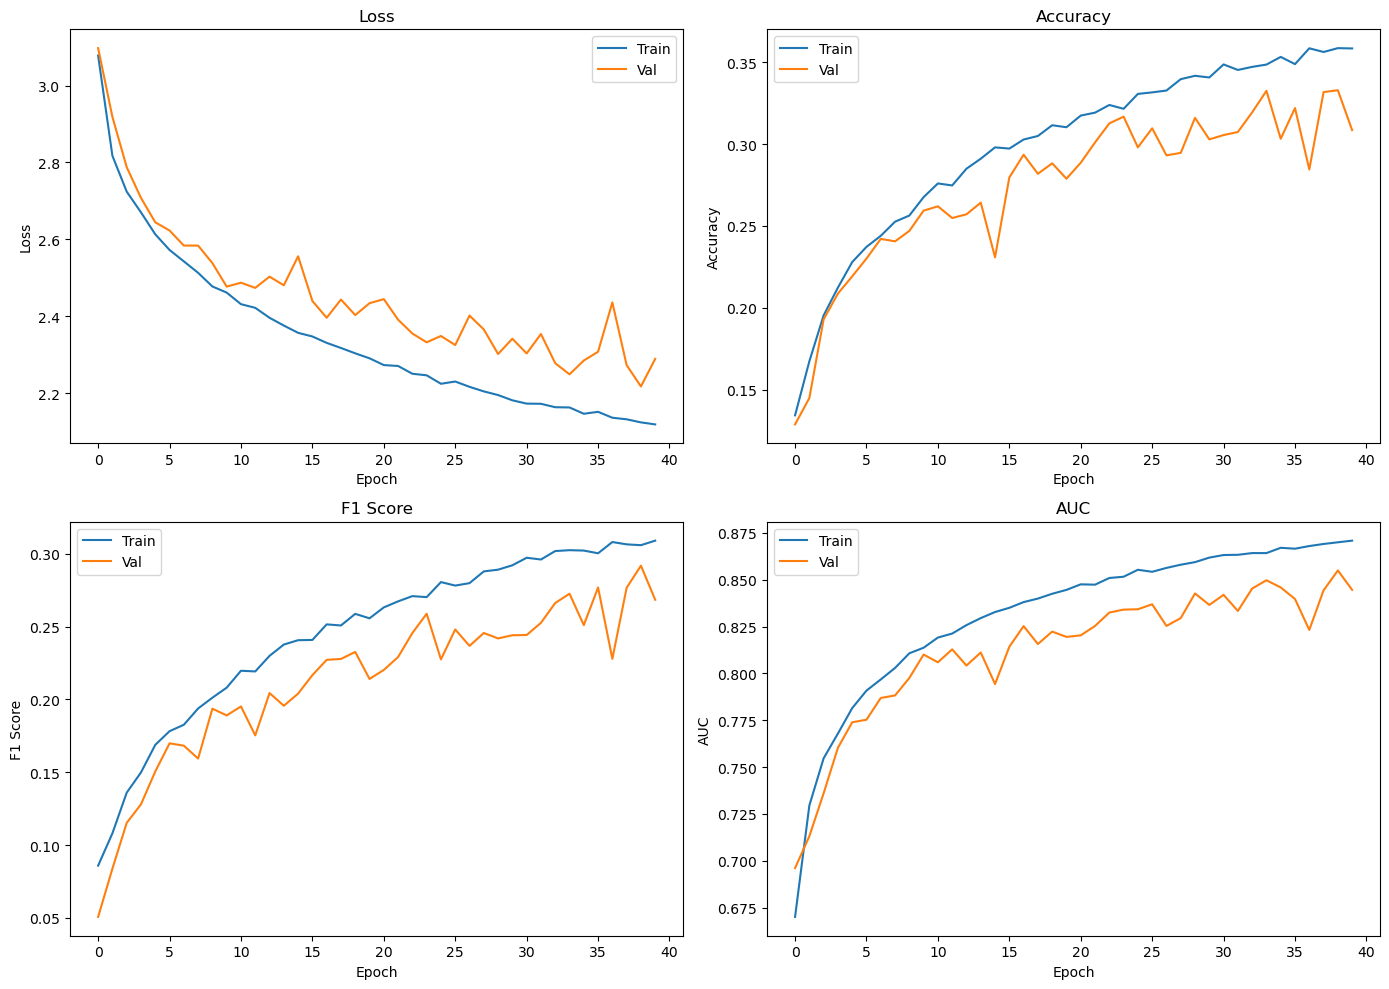

In [26]:
plot_history(third_resnet50_results)

From the results we can see that the scores really improved compared to the previous model, probably the Random Augmentation was more hurting then helping the model, so by switch to augmentations more suitable to the dataset, we were able to achive better results. We can still observe some overfitting, that we can try to solve futher, by adding some other augmentation or play with dropout rate. 

For now since we believe we got score, we will try to unfreaze some of the layers of the ResNet model that we are using to see if we can improve even more this results

In [31]:
#O ResNet que estamos a usar como Base Model tem 175 layers
len(third_resnet50.base_model.layers)

175

In [ ]:
#Todos os layers do ResNet
for i,layer in enumerate(third_resnet50.base_model.layers):
    print(i,layer)

0 <InputLayer name=input_layer_3, built=True>
1 <ZeroPadding2D name=conv1_pad, built=True>
2 <Conv2D name=conv1_conv, built=True>
3 <BatchNormalization name=conv1_bn, built=True>
4 <Activation name=conv1_relu, built=True>
5 <ZeroPadding2D name=pool1_pad, built=True>
6 <MaxPooling2D name=pool1_pool, built=True>
7 <Conv2D name=conv2_block1_1_conv, built=True>
8 <BatchNormalization name=conv2_block1_1_bn, built=True>
9 <Activation name=conv2_block1_1_relu, built=True>
10 <Conv2D name=conv2_block1_2_conv, built=True>
11 <BatchNormalization name=conv2_block1_2_bn, built=True>
12 <Activation name=conv2_block1_2_relu, built=True>
13 <Conv2D name=conv2_block1_0_conv, built=True>
14 <Conv2D name=conv2_block1_3_conv, built=True>
15 <BatchNormalization name=conv2_block1_0_bn, built=True>
16 <BatchNormalization name=conv2_block1_3_bn, built=True>
17 <Add name=conv2_block1_add, built=True>
18 <Activation name=conv2_block1_out, built=True>
19 <Conv2D name=conv2_block2_1_conv, built=True>
20 <BatchNo

Do Layer 144 até ao 175 temos o quinto convolutional layer, parece ser uma boa dar unfreaze a estes layers, pois são os layers que detetam features mais complexas

In [32]:
#tenho de escolher os index 143 ao 174
third_resnet50.base_model.trainable = True            #Descongelar o modelo todo
for layer in third_resnet50.base_model.layers[:143]:
    layer.trainable = False                           #Voltar a congelar todos os layers que não quero dar update
    

In [ ]:
#Podemo verificar que funcionou e os conv5_blocks estão unfreazed
for i,layer in enumerate(third_resnet50.base_model.layers):
    print(i,layer, "Trainable:", layer.trainable)

0 <InputLayer name=input_layer_3, built=True> Trainable: False
1 <ZeroPadding2D name=conv1_pad, built=True> Trainable: False
2 <Conv2D name=conv1_conv, built=True> Trainable: False
3 <BatchNormalization name=conv1_bn, built=True> Trainable: False
4 <Activation name=conv1_relu, built=True> Trainable: False
5 <ZeroPadding2D name=pool1_pad, built=True> Trainable: False
6 <MaxPooling2D name=pool1_pool, built=True> Trainable: False
7 <Conv2D name=conv2_block1_1_conv, built=True> Trainable: False
8 <BatchNormalization name=conv2_block1_1_bn, built=True> Trainable: False
9 <Activation name=conv2_block1_1_relu, built=True> Trainable: False
10 <Conv2D name=conv2_block1_2_conv, built=True> Trainable: False
11 <BatchNormalization name=conv2_block1_2_bn, built=True> Trainable: False
12 <Activation name=conv2_block1_2_relu, built=True> Trainable: False
13 <Conv2D name=conv2_block1_0_conv, built=True> Trainable: False
14 <Conv2D name=conv2_block1_3_conv, built=True> Trainable: False
15 <BatchNormali

Voltar a dar Compile do modelo, mas com um learning rate bastante baixo 

In [36]:
optimizer = SGD(learning_rate=0.00001, name="optimizer")
loss = CategoricalCrossentropy(name="loss")
epochs= 40

In [37]:
third_resnet50.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [38]:
third_resnet50_tunned_results = third_resnet50.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs
)

Epoch 1/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 187s 545ms/step - accuracy: 0.3702 - auc: 0.8727 - f1_score: 0.3226 - loss: 2.0569 - val_accuracy: 0.3523 - val_auc: 0.8616 - val_f1_score: 0.2940 - val_loss: 2.1693
Epoch 2/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 181s 541ms/step - accuracy: 0.3862 - auc: 0.8839 - f1_score: 0.3364 - loss: 2.0302 - val_accuracy: 0.3613 - val_auc: 0.8647 - val_f1_score: 0.3143 - val_loss: 2.1476
Epoch 3/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 178s 532ms/step - accuracy: 0.3932 - auc: 0.8848 - f1_score: 0.3450 - loss: 2.0174 - val_accuracy: 0.3564 - val_auc: 0.8623 - val_f1_score: 0.3042 - val_loss: 2.1675
Epoch 4/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 178s 533ms/step - accuracy: 0.3966 - auc: 0.8853 - f1_score: 0.3452 - loss: 2.0145 - val_accuracy: 0.3602 - val_auc: 0.8656 - val_f1_score: 0.3197 - val_loss: 2.1433
Epoch 5/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 179s 538ms/step - accuracy: 0.3991 - auc: 0.8874 - f1_score: 0.3483 - loss: 1.9973 - val_accuracy: 0.3617 - val_auc: 0.8668 - val_f1_sco

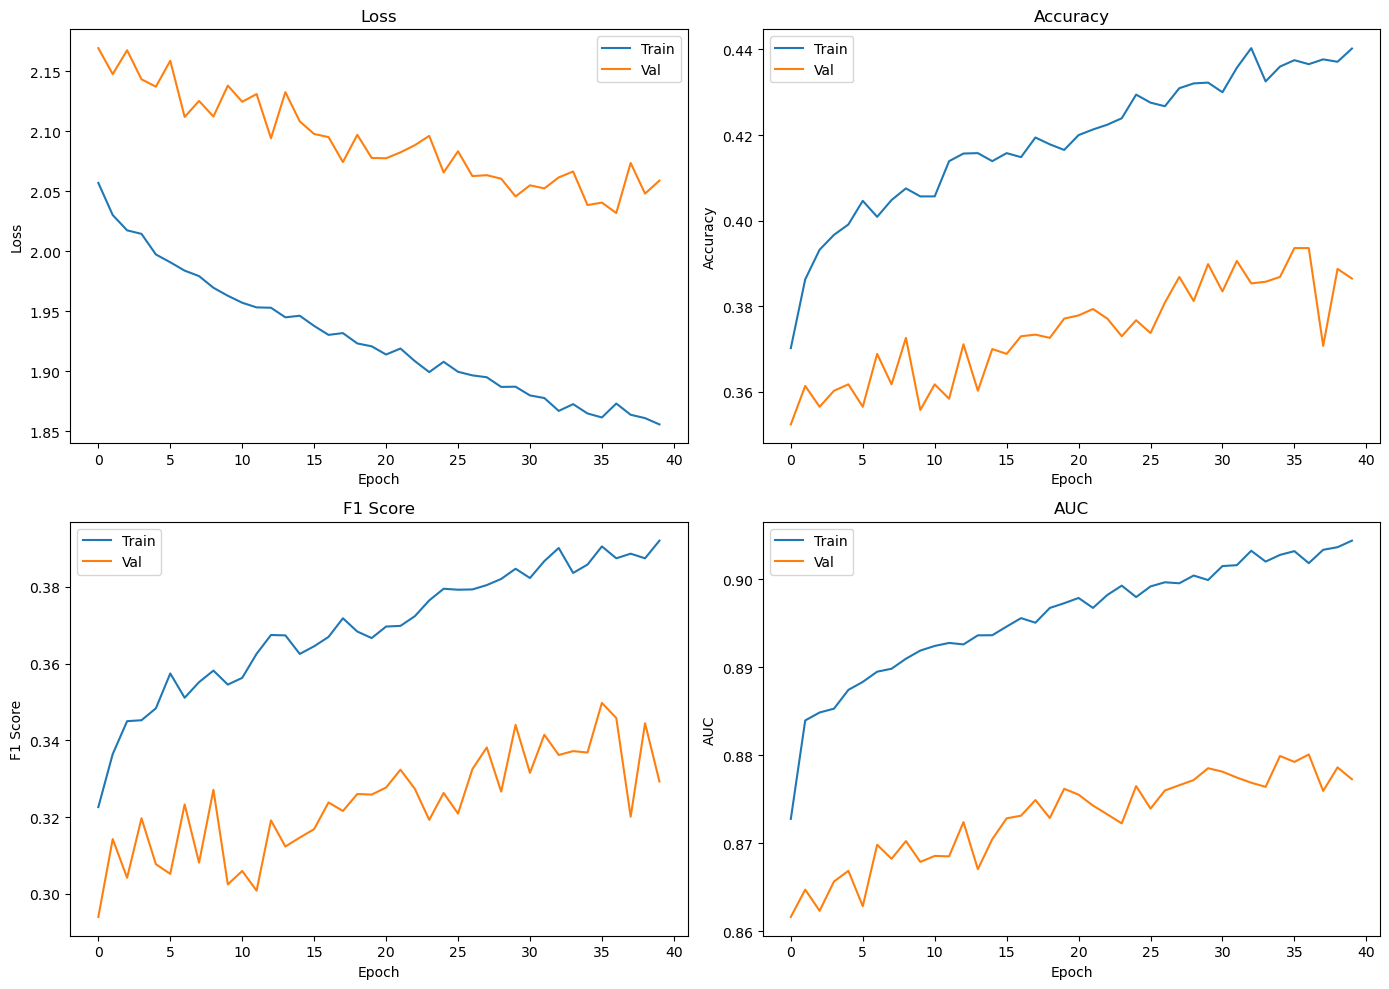

In [39]:
plot_history(third_resnet50_tunned_results)

Cometi um erro nas versões nos ultimos modelos, porque não coloquei os preprocess setps adequados para o modelo pretrainned, por isso vou criar uma nova versão mas com a pretraining certo e vou correr menos epochs para ser mais rádipo

In [7]:
class my_ResNet50_4(Model):
    """
    Pre_trainned ResNet50 + Drop_out + Random Rotation + Random flip + (preprocess adequado)

    """
    #Initialization
    def __init__(self):
        super().__init__(name="My_ResNet50_4")

        self.n_classes = 23
        self.Preprocessing_layer = keras.layers.Lambda(keras.applications.resnet.preprocess_input)
        self.RandRotation = RandomRotation(factor=(-0.05, 0.05), fill_mode="reflect", interpolation="bilinear")
        self.RandFlip = RandomFlip(mode="horizontal")
        self.base_model = ResNet50(include_top=False, weights="imagenet", classes=23)
        self.base_model.trainable = False  #Dar freaze ao modelo
        self.Globalmax_layer = GlobalMaxPool2D() #Usei GlobalMaxPool2D em vez do Flatten, porque o flatten gera um vetor muito longo
        self.Dense_1 = Dense(120, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.Preprocessing_layer(x)
        x = self.RandRotation(x)
        x = self.RandFlip(x)
        x = self.base_model(x, training = False) #Temos de ter training igual a false, mesmo tendo congelado o modelo em cima, porque                                    
        x = self.Globalmax_layer(x)                                       #os batchnormalization layers continuam a treinar e neste primeiro teste não queremos isso
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [11]:
Forth_resnet50 = my_ResNet50_4()
inputs = Input(shape=input_shape)
_ = Forth_resnet50.call(inputs)
Forth_resnet50.summary()

Model: "My_ResNet50_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 512, 512, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 16, 16, 2048)   │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_1          │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 120)            │       245,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         2,783 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,836,375 (90.93 MB)

 Trainable params: 248,663 (971.34 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [12]:
epochs = 5

loss= CategoricalCrossentropy(name="loss")
optimizer= SGD(learning_rate=0.002, name="optimizer")

categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]


In [15]:
Forth_resnet50.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [17]:
Forth_resnet50.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs,
    callbacks=EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
)

Epoch 1/5


I0000 00:00:1776171976.990597    6359 cuda_dnn.cc:461] Loaded cuDNN version 91700


334/334 ━━━━━━━━━━━━━━━━━━━━ 277s 796ms/step - accuracy: 0.2080 - auc: 0.7137 - f1_score: 0.1344 - loss: 2.9658 - val_accuracy: 0.2924 - val_auc: 0.7877 - val_f1_score: 0.1684 - val_loss: 2.5243
Epoch 2/5
334/334 ━━━━━━━━━━━━━━━━━━━━ 258s 773ms/step - accuracy: 0.3645 - auc: 0.8463 - f1_score: 0.2526 - loss: 2.2105 - val_accuracy: 0.3898 - val_auc: 0.8632 - val_f1_score: 0.2805 - val_loss: 2.1336
Epoch 3/5
334/334 ━━━━━━━━━━━━━━━━━━━━ 284s 852ms/step - accuracy: 0.4504 - auc: 0.8953 - f1_score: 0.3516 - loss: 1.8777 - val_accuracy: 0.4738 - val_auc: 0.9051 - val_f1_score: 0.3875 - val_loss: 1.8003
Epoch 4/5
334/334 ━━━━━━━━━━━━━━━━━━━━ 298s 778ms/step - accuracy: 0.5030 - auc: 0.9192 - f1_score: 0.4212 - loss: 1.6627 - val_accuracy: 0.5146 - val_auc: 0.9248 - val_f1_score: 0.4422 - val_loss: 1.6167
Epoch 5/5
334/334 ━━━━━━━━━━━━━━━━━━━━ 170s 509ms/step - accuracy: 0.5443 - auc: 0.9344 - f1_score: 0.4677 - loss: 1.5083 - val_accuracy: 0.5195 - val_auc: 0.9203 - val_f1_score: 0.4566 - va

optive um score bem melhor que anteriormente e o overfit está bué controlado.

Agora vou experimentar dar fine-tunning a este modelo, dando unfreaze ao último convolutional block

In [20]:
Forth_resnet50.base_model.trainable = True            #Descongelar o modelo todo
for layer in Forth_resnet50.base_model.layers[:143]:
    layer.trainable = False   

In [21]:
#Decreasing the learning rate for fine tunning
optimizer=SGD(learning_rate=0.00001, name="optimizer")

In [22]:
Forth_resnet50.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [23]:
Forth_resnet50_tunned_results = Forth_resnet50.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs,
    callbacks=EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
)

Epoch 1/5
334/334 ━━━━━━━━━━━━━━━━━━━━ 188s 546ms/step - accuracy: 0.5454 - auc: 0.9328 - f1_score: 0.4720 - loss: 1.4873 - val_accuracy: 0.5289 - val_auc: 0.9261 - val_f1_score: 0.4577 - val_loss: 1.5883
Epoch 2/5
334/334 ━━━━━━━━━━━━━━━━━━━━ 179s 536ms/step - accuracy: 0.5604 - auc: 0.9372 - f1_score: 0.4802 - loss: 1.4695 - val_accuracy: 0.5281 - val_auc: 0.9242 - val_f1_score: 0.4562 - val_loss: 1.5903
Epoch 3/5
334/334 ━━━━━━━━━━━━━━━━━━━━ 179s 537ms/step - accuracy: 0.5612 - auc: 0.9387 - f1_score: 0.4825 - loss: 1.4585 - val_accuracy: 0.5375 - val_auc: 0.9276 - val_f1_score: 0.4710 - val_loss: 1.5697
Epoch 4/5
334/334 ━━━━━━━━━━━━━━━━━━━━ 179s 536ms/step - accuracy: 0.5587 - auc: 0.9382 - f1_score: 0.4793 - loss: 1.4619 - val_accuracy: 0.5397 - val_auc: 0.9292 - val_f1_score: 0.4679 - val_loss: 1.5579
Epoch 5/5
334/334 ━━━━━━━━━━━━━━━━━━━━ 179s 535ms/step - accuracy: 0.5614 - auc: 0.9400 - f1_score: 0.4836 - loss: 1.4475 - val_accuracy: 0.5405 - val_auc: 0.9273 - val_f1_score: 0

A performance melhorou vou tentar, descongelar modelo todo

In [37]:
Forth_resnet50.base_model.trainable = True 
for layer in Forth_resnet50.base_model.layers:
    layer.trainable = True

In [38]:
#Decreasing the learning rate for fine tunning
optimizer=SGD(learning_rate=0.00001, name="optimizer")
Forth_resnet50.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [39]:
#Podemo verificar que funcionou e os conv5_blocks estão unfreazed
for i,layer in enumerate(Forth_resnet50.base_model.layers):
    print(i,layer, "Trainable:", layer.trainable)

0 <InputLayer name=input_layer_1, built=True> Trainable: True
1 <ZeroPadding2D name=conv1_pad, built=True> Trainable: True
2 <Conv2D name=conv1_conv, built=True> Trainable: True
3 <BatchNormalization name=conv1_bn, built=True> Trainable: True
4 <Activation name=conv1_relu, built=True> Trainable: True
5 <ZeroPadding2D name=pool1_pad, built=True> Trainable: True
6 <MaxPooling2D name=pool1_pool, built=True> Trainable: True
7 <Conv2D name=conv2_block1_1_conv, built=True> Trainable: True
8 <BatchNormalization name=conv2_block1_1_bn, built=True> Trainable: True
9 <Activation name=conv2_block1_1_relu, built=True> Trainable: True
10 <Conv2D name=conv2_block1_2_conv, built=True> Trainable: True
11 <BatchNormalization name=conv2_block1_2_bn, built=True> Trainable: True
12 <Activation name=conv2_block1_2_relu, built=True> Trainable: True
13 <Conv2D name=conv2_block1_0_conv, built=True> Trainable: True
14 <Conv2D name=conv2_block1_3_conv, built=True> Trainable: True
15 <BatchNormalization name=con

In [44]:
Forth_resnet50_tunned_full_results = Forth_resnet50.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs,
    callbacks=EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
)

Epoch 1/5


W0000 00:00:1776176289.686325    6365 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.18GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


1334/1334 ━━━━━━━━━━━━━━━━━━━━ 374s 279ms/step - accuracy: 0.5633 - auc: 0.9397 - f1_score: 0.4864 - loss: 1.4427 - val_accuracy: 0.5465 - val_auc: 0.9286 - val_f1_score: 0.4752 - val_loss: 1.5481
Epoch 2/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 371s 278ms/step - accuracy: 0.5767 - auc: 0.9427 - f1_score: 0.5027 - loss: 1.4087 - val_accuracy: 0.5506 - val_auc: 0.9323 - val_f1_score: 0.4805 - val_loss: 1.5145
Epoch 3/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 376s 282ms/step - accuracy: 0.5829 - auc: 0.9427 - f1_score: 0.5083 - loss: 1.3952 - val_accuracy: 0.5570 - val_auc: 0.9349 - val_f1_score: 0.4932 - val_loss: 1.4947
Epoch 4/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 372s 279ms/step - accuracy: 0.5873 - auc: 0.9450 - f1_score: 0.5146 - loss: 1.3744 - val_accuracy: 0.5588 - val_auc: 0.9357 - val_f1_score: 0.4884 - val_loss: 1.4810
Epoch 5/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 375s 281ms/step - accuracy: 0.5925 - auc: 0.9465 - f1_score: 0.5210 - loss: 1.3530 - val_accuracy: 0.5753 - val_auc: 0.9372 - val_f1_score: 0

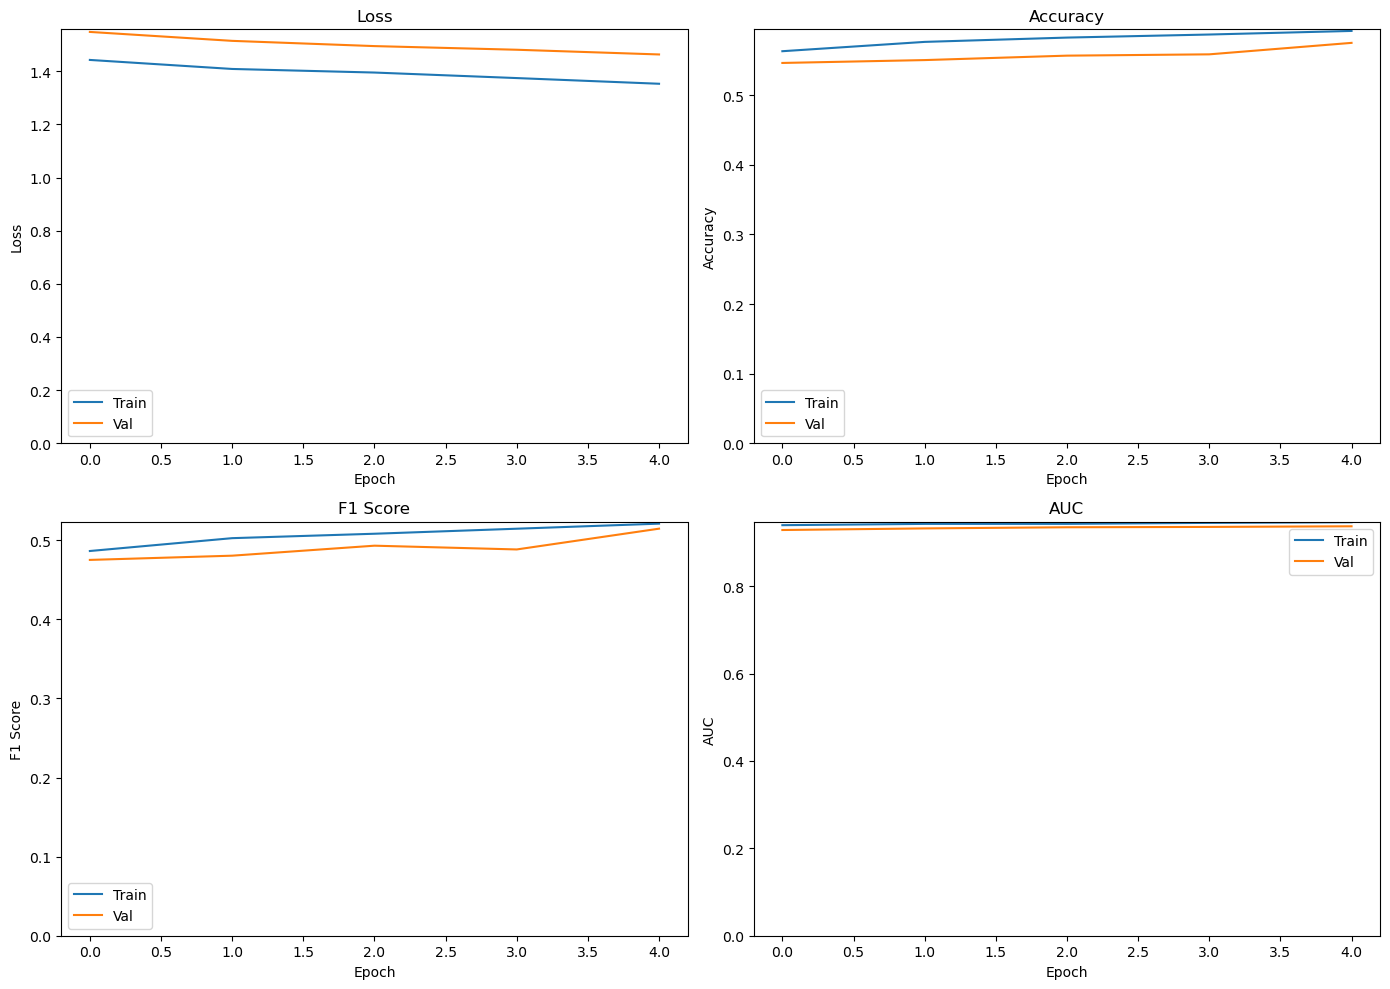

In [47]:
plot_history(Forth_resnet50_tunned_full_results)

Depois de de dar fine-tunning com o modelo todo unfrozen, melhoramos o score e continuamos a estar muito bem de overfiting, no entanto não é um score muito satisfatório

## EfficinteNetV2S

In [48]:
from keras.applications import EfficientNetV2S

meti as augmentations antes do preprocess e tentei global average pooling

In [53]:
class my_EfficientNetV2S_1(Model):
    """
    Pre_trainned EfficienteNetV2S+ Drop_out + Random Rotation + Random flip 

    """
    #Initialization
    def __init__(self):
        super().__init__(name="EfficientNetV2S_1")

        self.n_classes = 23
        self.RandRotation = RandomRotation(factor=(-0.05, 0.05), fill_mode="reflect", interpolation="bilinear")
        self.RandFlip = RandomFlip(mode="horizontal")
        self.Preprocessing_layer = keras.layers.Lambda(keras.applications.efficientnet_v2.preprocess_input)
        self.base_model = EfficientNetV2S(include_top=False, weights="imagenet", classes=23)
        self.base_model.trainable = False  #Dar freaze ao modelo
        self.Globalavg_layer = GlobalAveragePooling2D()
        self.Dense_1 = Dense(120, activation="relu")
        self.Drop_out =Dropout(rate=0.2)
        self.Dense_2 = Dense(self.n_classes, activation="softmax")


    def call(self, Inputs):

        x = Inputs

        x = self.RandRotation(x)
        x = self.RandFlip(x)
        x = self.Preprocessing_layer(x)
        x = self.base_model(x, training = False) #Temos de ter training igual a false, mesmo tendo congelado o modelo em cima, porque                                    
        x = self.Globalavg_layer(x)                                       #os batchnormalization layers continuam a treinar e neste primeiro teste não queremos isso
        x = self.Dense_1(x)
        x = self.Drop_out(x)
        x = self.Dense_2(x)

        return x

In [54]:
First_efficienteNet = my_EfficientNetV2S_1()
inputs = Input(shape=input_shape)
_ = First_efficienteNet.call(inputs)
First_efficienteNet.summary()

Model: "EfficientNetV2S_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_5               │ (None, 512, 512, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_5 (RandomFlip)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_4 (Lambda)               │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 16, 16, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 120)            │       153,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 23)             │         2,783 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,487,863 (78.15 MB)

 Trainable params: 156,503 (611.34 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

In [55]:
epochs = 5

loss= CategoricalCrossentropy(name="loss")
optimizer= SGD(learning_rate=0.002, name="optimizer")

categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]

In [56]:
First_efficienteNet.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [57]:
#Primeira run de efficientNet com modelo frozen

First_efficienteNet_results = First_efficienteNet.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs,
    callbacks=EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
)

Epoch 1/5
   1/1334 ━━━━━━━━━━━━━━━━━━━━ 3:44:32 10s/step - accuracy: 0.0000e+00 - auc: 0.3619 - f1_score: 0.0000e+00 - loss: 3.3337

W0000 00:00:1776179630.622530    6362 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.86GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


1334/1334 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.1651 - auc: 0.6660 - f1_score: 0.1008 - loss: 2.9415

W0000 00:00:1776179825.651868    6364 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.70GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


1334/1334 ━━━━━━━━━━━━━━━━━━━━ 206s 147ms/step - accuracy: 0.2533 - auc: 0.7601 - f1_score: 0.1545 - loss: 2.7202 - val_accuracy: 0.3591 - val_auc: 0.8522 - val_f1_score: 0.2448 - val_loss: 2.3650
Epoch 2/5
 167/1334 ━━━━━━━━━━━━━━━━━━━━ 2:13 114ms/step - accuracy: 0.3785 - auc: 0.8610 - f1_score: 0.2321 - loss: 2.3021

KeyboardInterrupt: 

A primeira epoch não teve o crescimento esperado, então paramos e vamos tentar mudar algumas coisa para melhorar, primeiro vamos tentar usar o adam em vez do SGD

In [60]:
Second_efficienteNet = my_EfficientNetV2S_1()
epochs = 5

loss= CategoricalCrossentropy(name="loss")
optimizer= Adam(learning_rate=0.002, name="optimizer")

categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]

In [61]:
Second_efficienteNet.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [62]:
Second_efficienteNet_results = Second_efficienteNet.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs,
    callbacks=EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
)

Epoch 1/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 206s 146ms/step - accuracy: 0.6325 - auc: 0.9538 - f1_score: 0.5987 - loss: 1.2460 - val_accuracy: 0.7204 - val_auc: 0.9725 - val_f1_score: 0.6938 - val_loss: 0.9264
Epoch 2/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 189s 142ms/step - accuracy: 0.7651 - auc: 0.9809 - f1_score: 0.7461 - loss: 0.7695 - val_accuracy: 0.7414 - val_auc: 0.9733 - val_f1_score: 0.7175 - val_loss: 0.8806
Epoch 3/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 189s 142ms/step - accuracy: 0.8152 - auc: 0.9874 - f1_score: 0.8007 - loss: 0.5954 - val_accuracy: 0.7489 - val_auc: 0.9694 - val_f1_score: 0.7376 - val_loss: 0.8993
Epoch 4/5
1334/1334 ━━━━━━━━━━━━━━━━━━━━ 196s 147ms/step - accuracy: 0.8440 - auc: 0.9910 - f1_score: 0.8316 - loss: 0.4815 - val_accuracy: 0.7354 - val_auc: 0.9635 - val_f1_score: 0.7221 - val_loss: 0.9948


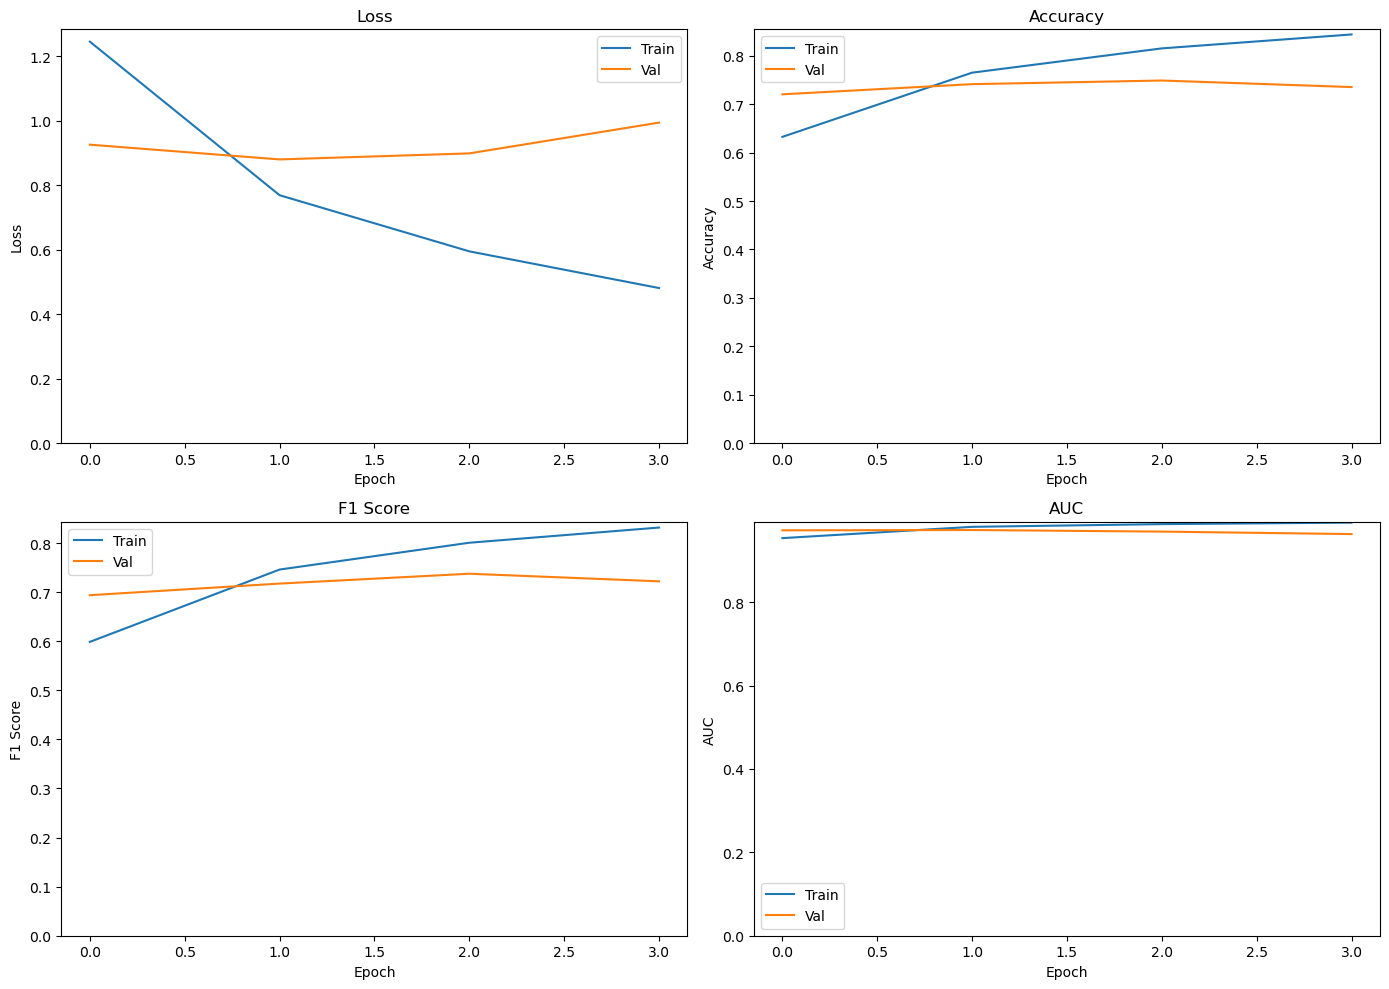

In [63]:
plot_history(Second_efficienteNet_results)

Agora tentar fazer fine tunning

In [67]:
len(Second_efficienteNet.base_model.layers)

513

In [72]:
for i, layer in enumerate(Second_efficienteNet.base_model.layers):
    layer.trainable = True

In [74]:
epochs = 5

loss= CategoricalCrossentropy(name="loss")
optimizer= Adam(learning_rate=0.00001, name="optimizer")

categorical_accuracy = CategoricalAccuracy(name="accuracy")
auc = AUC(name="auc")
f1_score = F1Score(average="macro", name="f1_score")  #pensar em usar weighted em vez de macro
metrics = [categorical_accuracy, auc, f1_score]

In [75]:
Second_efficienteNet.compile(loss=loss, optimizer=optimizer, metrics=metrics)

In [78]:
Second_efficienteNet_Tunned_results = Second_efficienteNet.fit(
    train_df,
    validation_data=val_df,
    epochs=epochs,
    callbacks=EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
)

Epoch 1/5


W0000 00:00:1776183860.112449    6364 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.65GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


2668/2668 ━━━━━━━━━━━━━━━━━━━━ 743s 278ms/step - accuracy: 0.8633 - auc: 0.9930 - f1_score: 0.8525 - loss: 0.4381 - val_accuracy: 0.8325 - val_auc: 0.9859 - val_f1_score: 0.8172 - val_loss: 0.5859
Epoch 2/5
2668/2668 ━━━━━━━━━━━━━━━━━━━━ 9504s 4s/step - accuracy: 0.9329 - auc: 0.9980 - f1_score: 0.9269 - loss: 0.2250 - val_accuracy: 0.8343 - val_auc: 0.9836 - val_f1_score: 0.8221 - val_loss: 0.5847
Epoch 3/5
2668/2668 ━━━━━━━━━━━━━━━━━━━━ 976s 366ms/step - accuracy: 0.9671 - auc: 0.9994 - f1_score: 0.9641 - loss: 0.1162 - val_accuracy: 0.8433 - val_auc: 0.9800 - val_f1_score: 0.8299 - val_loss: 0.6262
Epoch 4/5
2668/2668 ━━━━━━━━━━━━━━━━━━━━ 1008s 378ms/step - accuracy: 0.9827 - auc: 0.9997 - f1_score: 0.9812 - loss: 0.0637 - val_accuracy: 0.8403 - val_auc: 0.9765 - val_f1_score: 0.8284 - val_loss: 0.6622


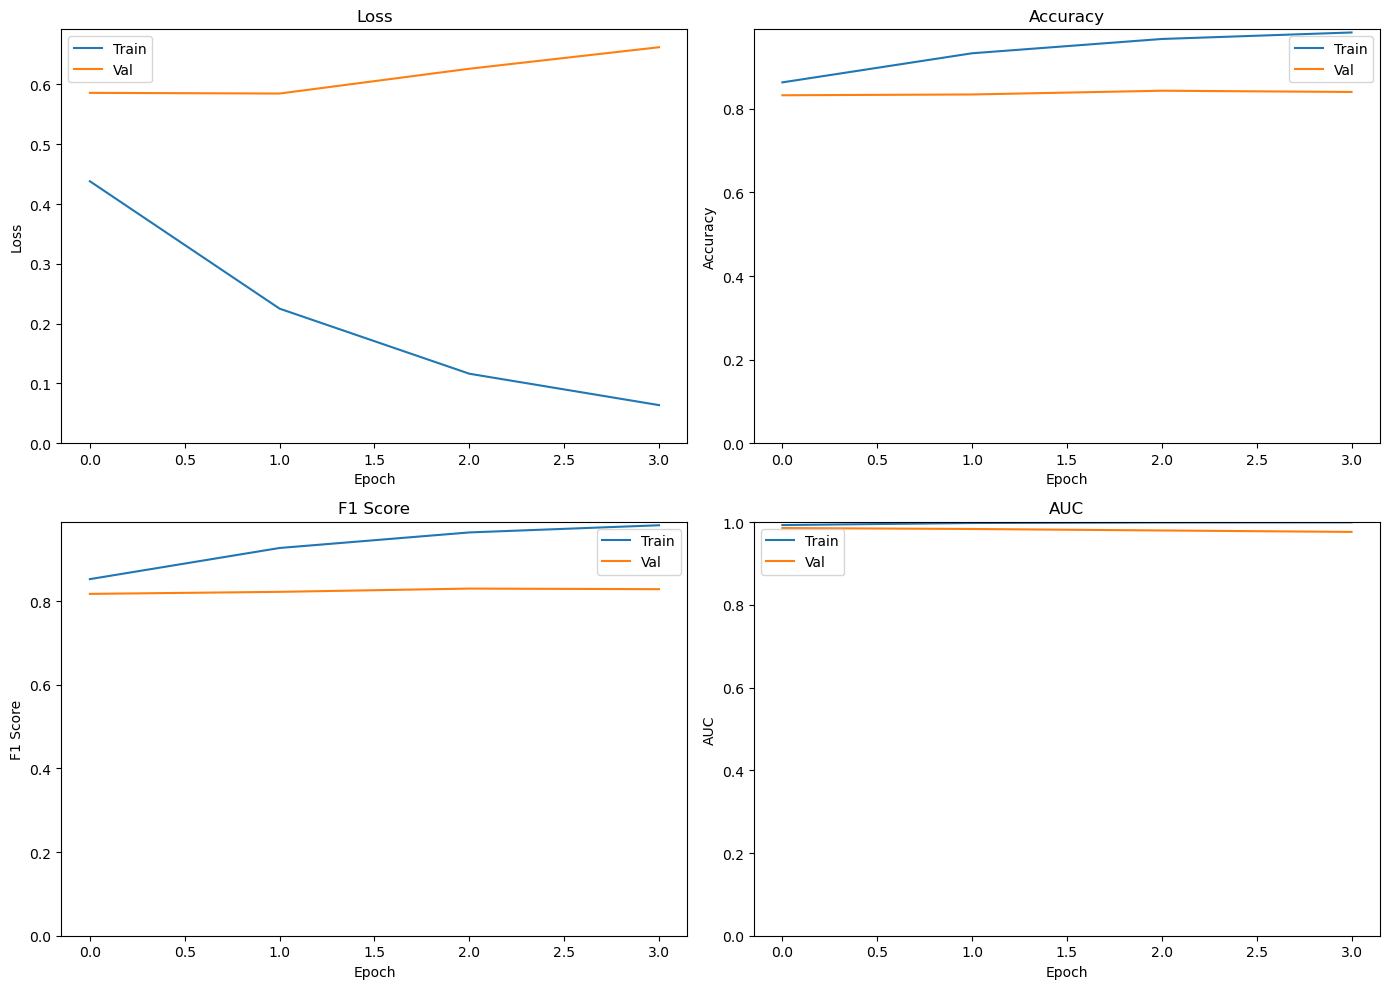

In [79]:
plot_history(Second_efficienteNet_Tunned_results)